In [1]:
import torch
from torch import nn
from d2l import torch as d2l

In [ ]:
# Attention Heatmap Function

# matrices Shape:
# [
#   Display Row,
#   Display Column,
#   Query 수,
#   Key 수,
# ]

def show_heatmaps(
    matrices: torch.Tensor,
    xlabel: str,
    ylabel: str,
    titles: list[str] | None = None,
    figsize: tuple[float, float] = (
        2.5,
        2.5,
    ),
    cmap: str = "Reds",
) -> None:
    d2l.use_svg_display()

    num_rows, num_cols, _, _ = (
        matrices.shape
    )

    figure, axes = d2l.plt.subplots(
        num_rows,
        num_cols,
        figsize=figsize,
        sharex=True,
        sharey=True,
        squeeze=False,
    )

    last_image = None

    for row_index, (
        row_axes,
        row_matrices,
    ) in enumerate(
        zip(
            axes,
            matrices,
            strict=True,
        )
    ):
        for column_index, (
            axis,
            matrix,
        ) in enumerate(
            zip(
                row_axes,
                row_matrices,
                strict=True,
            )
        ):
            last_image = axis.imshow(
                matrix.detach().cpu().numpy(),
                cmap=cmap,
            )

            if row_index == num_rows - 1:
                axis.set_xlabel(
                    xlabel
                )

            if column_index == 0:
                axis.set_ylabel(
                    ylabel
                )

            if titles is not None:
                axis.set_title(
                    titles[column_index]
                )

    if last_image is not None:
        figure.colorbar(
            last_image,
            ax=axes,
            shrink=0.6,
        )


Attention Weight shape: (1, 1, 10, 10)
Weight sum for each Query: tensor([[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]])
tensor([[[[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]]]])


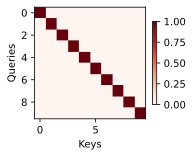

In [ ]:
# Identity Attention Visualization

attention_weights = torch.eye(
    10
).reshape(
    1,
    1,
    10,
    10,
)

show_heatmaps(
    attention_weights,
    xlabel="Keys",
    ylabel="Queries",
)

print(
    "Attention Weight shape:",
    tuple(attention_weights.shape)
)

print(
    "Weight sum for each Query:",
    attention_weights.sum(dim=-1),
)

Attention outputs:
tensor([[ 10., 100.],
        [ 23., 230.],
        [ 30., 300.]])


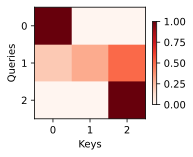

In [ ]:
# Attention Weight [Q, K] @ Values [K, V]
#  → Attention Output [Q, V]


# Attention Weight: [Query, Key]
attention_weights = torch.tensor([
    [1.0, 0.0, 0.0],
    [0.2, 0.3, 0.5],
    [0.0, 0.0, 1.0],
])

# Values: [Key, Value Feature]
values = torch.tensor([
    [10.0, 100.0],
    [20.0, 200.0],
    [30.0, 300.0],
])

# Attention Output:
# [Query, Key] @ [Key, Value Feature] = [Query, Value Feature]
attention_outputs = (
    attention_weights @ values
)

show_heatmaps(
    attention_weights.reshape(
        1,
        1,
        3,
        3,
    ),
    xlabel="Keys",
    ylabel="Queries",
)

print(
    "Attention outputs:"
)
print(
    attention_outputs
)